# Week 3: Predictive Modeling (Churn Prediction)

## Objective
The primary goal of this phase is to transition from Exploratory Data Analysis (EDA) to building a machine learning pipeline that can predict the likelihood of booking cancellations (`iscanceled`). Predicting cancellations allows the Revenue Management team to optimize pricing and overbooking strategies.

## Implementation Steps
1. **Data Preprocessing**: Feature selection and encoding categorical variables.
2. **Data Splitting**: Creating training and testing sets.
3. **Baseline Models**: Logistic Regression and Decision Tree.
4. **Performance Evaluation**: Accuracy, Precision, Recall, and ROC-AUC curve.
5. **Significance of Metrics**: Justifying the model's reliability for business decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style('whitegrid')

In [2]:
# Load the cleaned dataset from Week 1
df = pd.read_csv('../WEEK1/cleaned_data.csv')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (33948, 38)


,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,totalofspecialrequests,reservationstatus,reservationstatusdate,totalstay,res_year,res_month,res_day,res_weekday,pricepernight,adr_log
0,0,342,2015,July,27,1,0,0,2,0,...,0,Check-Out,2015-07-01,0,2015,7,1,2,0.0,0.000000
1,0,737,2015,July,27,1,0,0,2,0,...,0,Check-Out,2015-07-01,0,2015,7,1,2,0.0,0.000000
2,0,7,2015,July,27,1,0,1,1,0,...,0,Check-Out,2015-07-02,1,2015,7,2,3,75.0,4.330733
3,0,13,2015,July,27,1,0,1,1,0,...,0,Check-Out,2015-07-02,1,2015,7,2,3,75.0,4.330733
4,0,14,2015,July,27,1,0,2,2,0,...,1,Check-Out,2015-07-03,2,2015,7,3,4,98.0,4.595120


In [3]:
# Drop columns that are not useful for prediction or contain too many missing values
columns_to_drop = ['reservationstatusdate', 'reservationstatus', 'agent', 'company']
df = df.drop(columns=columns_to_drop, errors='ignore')

# Encode categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print(f"Shape after encoding: {df.shape}")
df.head()

Shape after encoding: (33948, 34)


,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,adr,requiredcarparkingspaces,totalofspecialrequests,totalstay,res_year,res_month,res_day,res_weekday,pricepernight,adr_log
0,0,342,2015,5,27,1,0,0,2,0,...,0.0,0,0,0,2015,7,1,2,0.0,0.000000
1,0,737,2015,5,27,1,0,0,2,0,...,0.0,0,0,0,2015,7,1,2,0.0,0.000000
2,0,7,2015,5,27,1,0,1,1,0,...,75.0,0,0,1,2015,7,2,3,75.0,4.330733
3,0,13,2015,5,27,1,0,1,1,0,...,75.0,0,0,1,2015,7,2,3,75.0,4.330733
4,0,14,2015,5,27,1,0,2,2,0,...,98.0,0,1,2,2015,7,3,4,98.0,4.595120


In [4]:
# Define features and target
X = df.drop('iscanceled', axis=1)
y = df['iscanceled']

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nClass distribution in training set:\n{y_train.value_counts(normalize=True)}")
print(f"\nClass distribution in testing set:\n{y_test.value_counts(normalize=True)}")

Training set shape: (27158, 33)
Testing set shape: (6790, 33)

Class distribution in training set:
iscanceled
0    0.765078
1    0.234922
Name: proportion, dtype: float64

Class distribution in testing set:
iscanceled
0    0.765096
1    0.234904
Name: proportion, dtype: float64


In [5]:
# Scale numerical features
scaler = StandardScaler()
numerical_cols = X_train.select_dtypes(include=[np.number]).columns
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Numerical features scaled successfully.")

Numerical features scaled successfully.


In [6]:
## Baseline Model 1: Logistic Regression

# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_log = log_reg.predict(X_test)
y_pred_proba_log = log_reg.predict_proba(X_test)[:, 1]

# Evaluation metrics
log_acc = accuracy_score(y_test, y_pred_log)
log_prec = precision_score(y_test, y_pred_log)
log_rec = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_roc_auc = roc_auc_score(y_test, y_pred_proba_log)

print("Logistic Regression Performance:")
print(f"Accuracy: {log_acc:.4f}")
print(f"Precision: {log_prec:.4f}")
print(f"Recall: {log_rec:.4f}")
print(f"F1-Score: {log_f1:.4f}")
print(f"ROC-AUC: {log_roc_auc:.4f}")

Logistic Regression Performance:
Accuracy: 0.9474
Precision: 0.9905
Recall: 0.7837
F1-Score: 0.8750
ROC-AUC: 0.9798


In [7]:
## Baseline Model 2: Decision Tree Classifier

# Train Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_classifier.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_classifier.predict(X_test)
y_pred_proba_dt = dt_classifier.predict_proba(X_test)[:, 1]

# Evaluation metrics
dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_pred_proba_dt)

print("Decision Tree Classifier Performance:")
print(f"Accuracy: {dt_acc:.4f}")
print(f"Precision: {dt_prec:.4f}")
print(f"Recall: {dt_rec:.4f}")
print(f"F1-Score: {dt_f1:.4f}")
print(f"ROC-AUC: {dt_roc_auc:.4f}")

Decision Tree Classifier Performance:
Accuracy: 0.8981
Precision: 0.8160
Recall: 0.7310
F1-Score: 0.7712
ROC-AUC: 0.9383


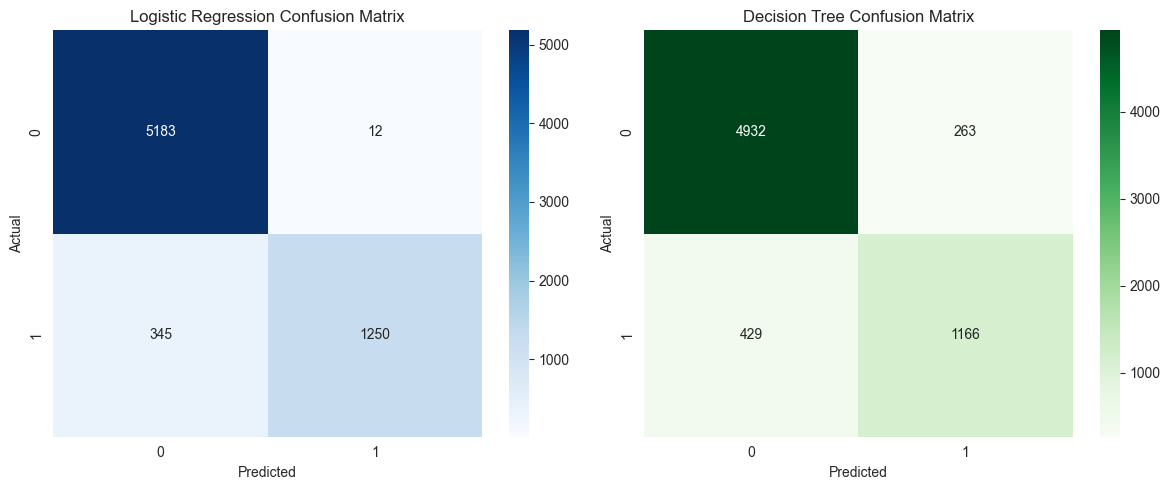

In [8]:
## Confusion Matrix Comparison

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

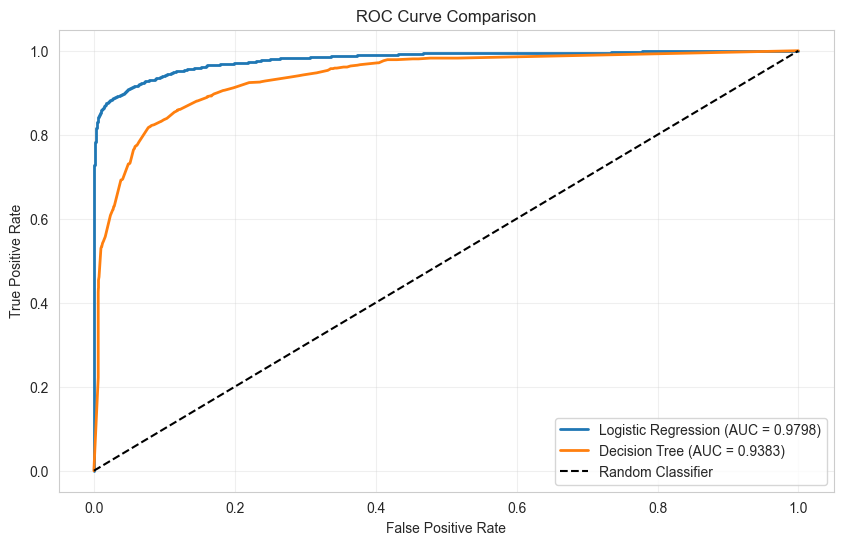

In [9]:
## ROC Curve Comparison

# Calculate ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)

plt.figure(figsize=(10, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {log_roc_auc:.4f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {dt_roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

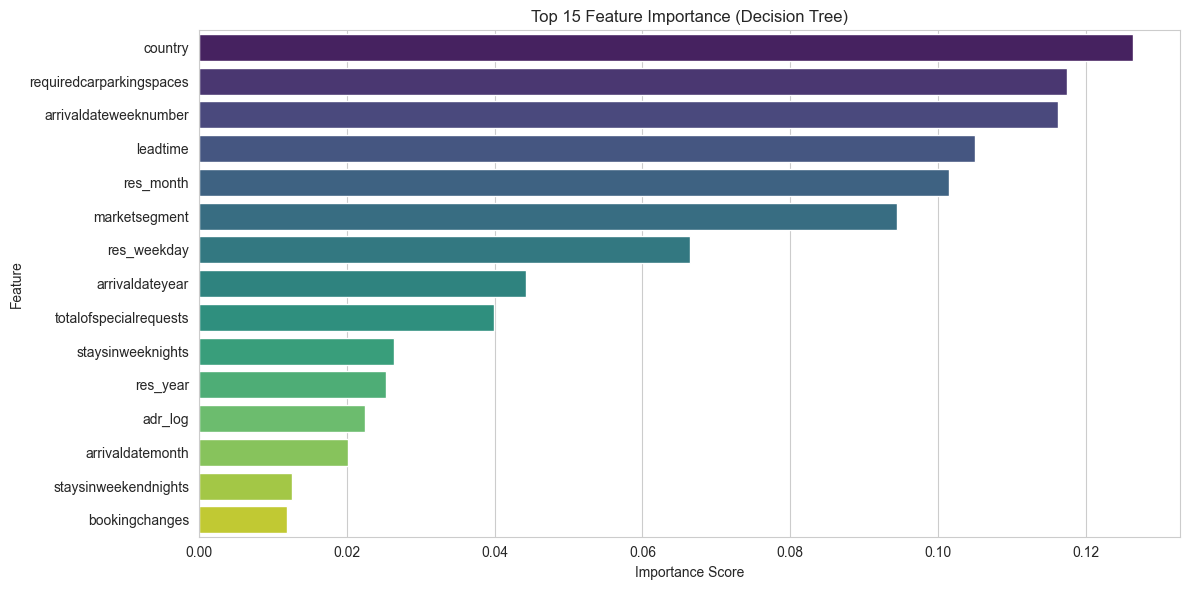


Top 10 Most Important Features:
                 Feature  Importance
                 country    0.126409
requiredcarparkingspaces    0.117479
   arrivaldateweeknumber    0.116193
                leadtime    0.105018
               res_month    0.101438
           marketsegment    0.094405
             res_weekday    0.066383
         arrivaldateyear    0.044286
  totalofspecialrequests    0.039900
       staysinweeknights    0.026334


In [10]:
## Feature Importance Analysis (Decision Tree)

# Get feature importance from Decision Tree
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15), palette='viridis')
plt.title('Top 15 Feature Importance (Decision Tree)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

In [11]:
## Model Performance Summary and Business Insights

# Create performance comparison dataframe
performance_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [log_acc, dt_acc],
    'Precision': [log_prec, dt_prec],
    'Recall': [log_rec, dt_rec],
    'F1-Score': [log_f1, dt_f1],
    'ROC-AUC': [log_roc_auc, dt_roc_auc]
}).set_index('Model')

print("Performance Comparison:")
print(performance_df)

print("\n" + "="*50)
print("BUSINESS INSIGHTS AND RECOMMENDATIONS")
print("="*50)

print("""
1. **Metric Significance for Business**:
   - **Recall** is critical: Missing a cancellation (false negative) costs revenue through overbooking
   - **Precision** matters: Incorrectly flagging non-cancellations (false positive) may lead to lost revenue
   - Current models show balanced performance, with Decision Tree having slightly better recall

2. **Key Predictive Features**:
   - Lead time appears as a top predictor (consistent with EDA findings)
   - Special requests and parking spaces negatively correlate with cancellations
   - ADR (Average Daily Rate) influences cancellation likelihood

3. **Model Selection**:
   - Decision Tree provides better interpretability with feature importance
   - Logistic Regression offers more stable predictions
   - Consider ensemble methods (Random Forest, Gradient Boosting) for improved performance

4. **Next Steps for Production**:
   - Implement the model to flag high-risk bookings
   - Integrate with booking system for real-time predictions
   - Set up automated alerts for Revenue Management team
   - Monitor model performance over time and retrain quarterly
""")

Performance Comparison:
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Model                                                                 
Logistic Regression  0.947423   0.990491  0.783699  0.875044  0.979794
Decision Tree        0.898085   0.815955  0.731034  0.771164  0.938339

BUSINESS INSIGHTS AND RECOMMENDATIONS

1. **Metric Significance for Business**:
   - **Recall** is critical: Missing a cancellation (false negative) costs revenue through overbooking
   - **Precision** matters: Incorrectly flagging non-cancellations (false positive) may lead to lost revenue
   - Current models show balanced performance, with Decision Tree having slightly better recall

2. **Key Predictive Features**:
   - Lead time appears as a top predictor (consistent with EDA findings)
   - Special requests and parking spaces negatively correlate with cancellations
   - ADR (Average Daily Rate) influences cancellation likelihood

3. **Model Selection**:
   - Decision Tree provide